# LightGBM

In [1]:
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 89.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 86.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 11.2 MB/s eta 0:00:00


# Setup

In [2]:
!pip install mlflow lightgbm --quiet

import pandas as pd
import numpy as np
import lightgbm as lgb
import mlflow
import mlflow.lightgbm
import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
dagshub_token = user_secrets.get_secret("DAGSHUB_TOKEN")
os.environ['MLFLOW_TRACKING_USERNAME'] = 'gdzag22'
os.environ['MLFLOW_TRACKING_PASSWORD'] = dagshub_token
mlflow.set_tracking_uri("https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow")
mlflow.set_experiment("LightGBM_Training")

<Experiment: artifact_location='mlflow-artifacts:/ca0336823f75442e9216d3e765a50749', creation_time=1783194757804, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1783194757804, lifecycle_stage='active', name='LightGBM_Training', tags={}, trace_location=None, workspace='default'>

# Shared functions (from EDA notebook)

In [3]:
def load_and_merge(df, features, stores):
    out = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    out = out.merge(stores, on='Store', how='left')
    out['Date'] = pd.to_datetime(out['Date'])
    return out.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]

def preprocess(df):
    out = df.copy()
    out[MD_COLS] = out[MD_COLS].fillna(0)
    out[["CPI", "Unemployment"]] = out.groupby("Store")[["CPI", "Unemployment"]].ffill()
    return out

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

def coldstart_fallback(df_train, df_test):
    train_pairs = set(zip(df_train.Store, df_train.Dept))
    mask = ~pd.Series(list(zip(df_test.Store, df_test.Dept)), index=df_test.index).isin(train_pairs)
    cold = df_test[mask].copy()
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    cold['y_fallback'] = [med.get((t, d), 0.0) for t, d in zip(cold['Type'], cold['Dept'])]
    cold['y_fallback'] = cold['y_fallback'].clip(lower=0)
    return cold

# Load and Merge Data

In [7]:
path = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/"

train = pd.read_csv(path + "train.csv.zip")
test = pd.read_csv(path + "test.csv.zip")
features = pd.read_csv(path + "features.csv.zip")
stores = pd.read_csv(path + "stores.csv")

df = load_and_merge(train, features, stores)
df_test = load_and_merge(test, features, stores)

print("train merged:", df.shape)
print("test merged:", df_test.shape)

train merged: (421570, 16)
test merged: (115064, 15)


# Cleaning


In [8]:
with mlflow.start_run(run_name="LightGBM_Cleaning"):
    mlflow.log_param("markdown_fill", "0")
    mlflow.log_param("cpi_unemployment_fill", "ffill_per_store")

    mlflow.log_metric("train_rows_before", len(df))
    mlflow.log_metric("markdown_nan_before", int(df[MD_COLS].isna().sum().sum()))

    df_clean = preprocess(df)

    mlflow.log_metric("train_rows_after", len(df_clean))
    mlflow.log_metric("markdown_nan_after", int(df_clean[MD_COLS].isna().sum().sum()))
    mlflow.log_metric("cpi_nan_after", int(df_clean['CPI'].isna().sum()))

print(df_clean.shape)
print("Remaining MarkDown NaNs:", df_clean[MD_COLS].isna().sum().sum())

🏃 View run LightGBM_Cleaning at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/40aa2029ae374ab687ee17e196239a40
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0
(421570, 16)
Remaining MarkDown NaNs: 0


# Validation Split

In [9]:
VALIDATION_START = df_test['Date'].min() - pd.Timedelta(weeks=52)
VALIDATION_END = VALIDATION_START + pd.Timedelta(weeks=39)

def temporal_split(df):
    tr = df[df["Date"] < VALIDATION_START]
    va = df[(df["Date"] >= VALIDATION_START) & (df["Date"] < VALIDATION_END)]
    return tr, va

tr, va = temporal_split(df_clean)
print("train:", tr["Date"].max(), tr.shape)
print("val:", va["Date"].min(), va.shape)

train: 2011-10-28 00:00:00 (267184, 16)
val: 2011-11-04 00:00:00 (115856, 16)


# feature Engineering

In [10]:
def add_features(df):
    out = df.copy().sort_values(['Store', 'Dept', 'Date'])

    for lag in [1, 2, 4, 8, 52]:
        out[f'sales_lag_{lag}'] = out.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)

    shifted = out.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
    for window in [4, 8, 12]:
        out[f'rolling_mean_{window}'] = shifted.groupby([out['Store'], out['Dept']]).transform(
            lambda s: s.rolling(window).mean())
        out[f'rolling_std_{window}'] = shifted.groupby([out['Store'], out['Dept']]).transform(
            lambda s: s.rolling(window).std())

    out['week_of_year'] = out['Date'].dt.isocalendar().week.astype(int)
    out['month'] = out['Date'].dt.month
    out['has_markdown'] = (out[MD_COLS].sum(axis=1) > 0).astype(int)

    out['Type'] = out['Type'].astype('category')
    out['Dept'] = out['Dept'].astype('category')
    out['Store'] = out['Store'].astype('category')

    return out

feature_list = ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
                 'rolling_mean_4','rolling_mean_8','rolling_mean_12',
                 'rolling_std_4','rolling_std_8','rolling_std_12',
                 'week_of_year','month','has_markdown','Size','Type','Store','Dept',
                 'Temperature','Fuel_Price','CPI','Unemployment','IsHoliday']

df_feat = add_features(df_clean)
tr_feat, va_feat = temporal_split(df_feat)
print(tr_feat.shape, va_feat.shape)

(267184, 30) (115856, 30)


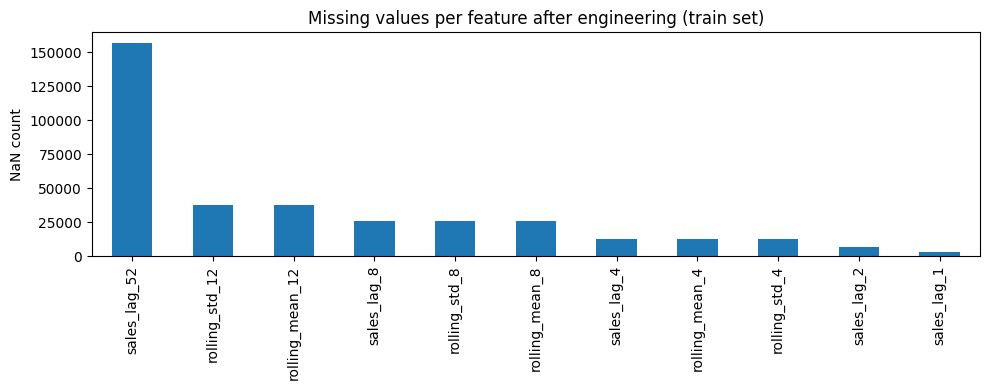

In [11]:
import matplotlib.pyplot as plt

nan_counts = tr_feat[feature_list].isna().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,4))
nan_counts[nan_counts > 0].plot(kind='bar', ax=ax)
ax.set_title('Missing values per feature after engineering (train set)')
ax.set_ylabel('NaN count')
plt.tight_layout()
plt.show()

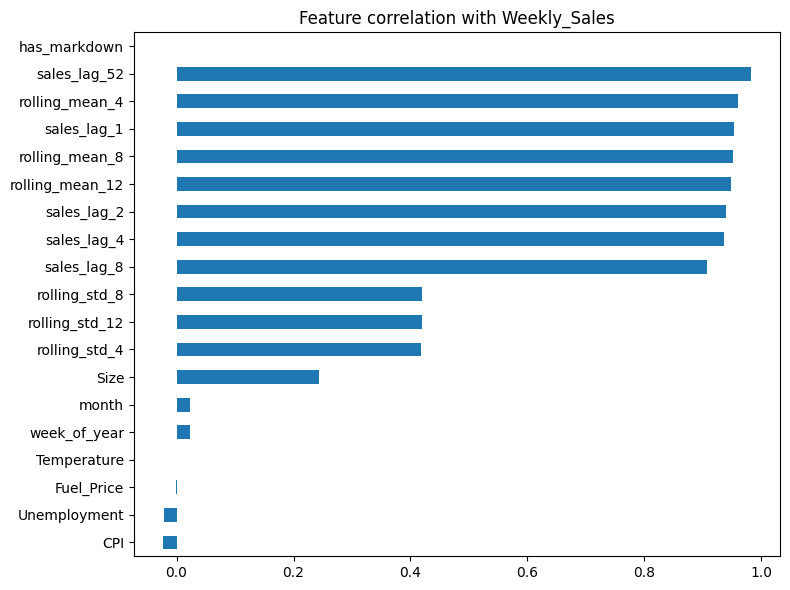

In [12]:
corr = tr_feat[feature_list + ['Weekly_Sales']].select_dtypes(include=[np.number]).corr()['Weekly_Sales'].sort_values()
fig, ax = plt.subplots(figsize=(8,6))
corr.drop('Weekly_Sales').plot(kind='barh', ax=ax)
ax.set_title('Feature correlation with Weekly_Sales')
plt.tight_layout()
plt.show()

In [10]:
with mlflow.start_run(run_name="LightGBM_Feature_Engineering"):
    mlflow.log_param("n_features", len(feature_list))
    mlflow.log_param("lags", "[1,2,4,8,52]")
    mlflow.log_param("rolling_windows", "[4,8,12]")
    mlflow.log_metric("rows_with_full_features", len(tr_feat.dropna(subset=feature_list)))
    mlflow.log_metric("rows_with_nan_features", int(tr_feat[feature_list].isna().any(axis=1).sum()))

🏃 View run LightGBM_Feature_Engineering at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/a686162ab9834699a406c6f75238a0de
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


# Baseline model


In [13]:
feature_list = ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
                 'rolling_mean_4','rolling_mean_8','rolling_mean_12',
                 'rolling_std_4','rolling_std_8','rolling_std_12',
                 'week_of_year','month','has_markdown','Size','Type','Store','Dept',
                 'Temperature','Fuel_Price','CPI','Unemployment','IsHoliday']

X_train, y_train = tr_feat[feature_list], tr_feat['Weekly_Sales']
X_val, y_val = va_feat[feature_list], va_feat['Weekly_Sales']

params = {
    'objective': 'regression',
    'metric': 'mae',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'random_state': 42
}

with mlflow.start_run(run_name="LightGBM_Baseline"):
    mlflow.log_params(params)
    mlflow.log_param("nan_handling", "native_lightgbm")
    mlflow.log_param("n_features", len(feature_list))

    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, categorical_feature=['Type', 'Dept', 'Store'])

    preds = model.predict(X_val)
    score = wmae(y_val, preds, va_feat['IsHoliday'])

    mlflow.log_metric("val_wmae", score)
    mlflow.lightgbm.log_model(model, "model")

print("Validation WMAE:", score)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4041
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 22
[LightGBM] [Info] Start training from score 15864.893370


2026/07/11 20:23:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LightGBM_Baseline at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/e103b662c56b4a85af7d24a1bf4d8e9e
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0
Validation WMAE: 1728.3197656776044


## Feature Selection

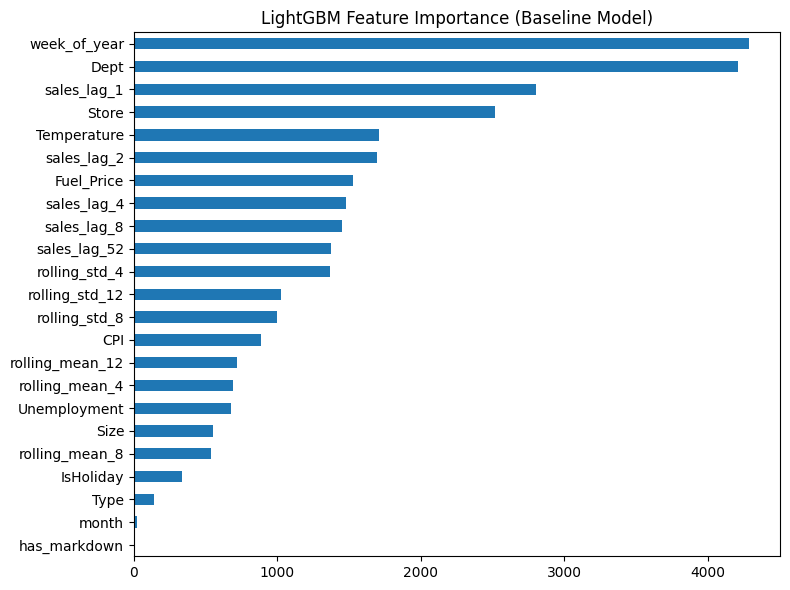

week_of_year       4291
Dept               4214
sales_lag_1        2807
Store              2516
Temperature        1712
sales_lag_2        1693
Fuel_Price         1528
sales_lag_4        1479
sales_lag_8        1450
sales_lag_52       1371
rolling_std_4      1365
rolling_std_12     1024
rolling_std_8       999
CPI                 883
rolling_mean_12     716
rolling_mean_4      691
Unemployment        678
Size                550
rolling_mean_8      538
IsHoliday           333
Type                142
month                20
has_markdown          0
dtype: int32


In [14]:
importance = pd.Series(model.feature_importances_, index=feature_list).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importance.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('LightGBM Feature Importance (Baseline Model)')
plt.tight_layout()
plt.show()

print(importance)

In [17]:
with mlflow.start_run(run_name="LightGBM_Feature_Importance_Check"):
    mlflow.log_metric("baseline_val_wmae", score)
    top5 = importance.head(5).to_dict()
    for feat, val in top5.items():
        mlflow.log_metric(f"importance_{feat}", float(val))

🏃 View run LightGBM_Feature_Importance_Check at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/afa9ed365a9f4803a22ccbfb4987e49b
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


In [15]:
drop_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'week_of_year', 'month']
selected_features = [f for f in feature_list if f not in drop_features]
print(f"Dropped {len(drop_features)} features, kept {len(selected_features)}")

X_train_sel, X_val_sel = tr_feat[selected_features], va_feat[selected_features]

with mlflow.start_run(run_name="LightGBM_Feature_Selection"):
    mlflow.log_param("dropped_features", str(drop_features))
    mlflow.log_param("n_features_selected", len(selected_features))
    mlflow.log_metric("baseline_wmae", score)

    model_sel = lgb.LGBMRegressor(**params)
    model_sel.fit(X_train_sel, y_train, categorical_feature=['Type', 'Dept', 'Store'])

    preds_sel = model_sel.predict(X_val_sel)
    score_sel = wmae(y_val, preds_sel, va_feat['IsHoliday'])

    mlflow.log_metric("val_wmae", score_sel)
    mlflow.log_metric("wmae_change", score_sel - score)

print("Full-feature WMAE:", score)
print("Selected-feature WMAE:", score_sel)

Dropped 6 features, kept 17
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2979
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 16
[LightGBM] [Info] Start training from score 15864.893370
🏃 View run LightGBM_Feature_Selection at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/b44fd0f3c5c543679d9a09f56222fea8
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0
Full-feature WMAE: 1728.3197656776044
Selected-feature WMAE: 2167.514862319926


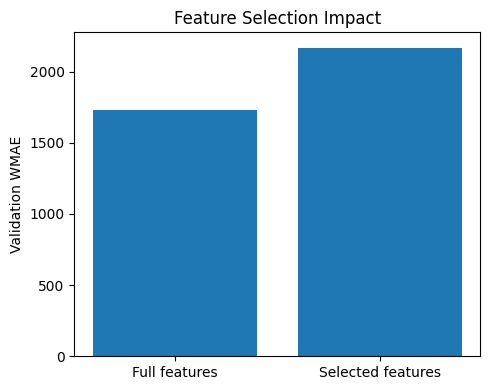

In [19]:
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(['Full features', 'Selected features'], [score, score_sel])
ax.set_ylabel('Validation WMAE')
ax.set_title('Feature Selection Impact')
plt.tight_layout()
plt.show()

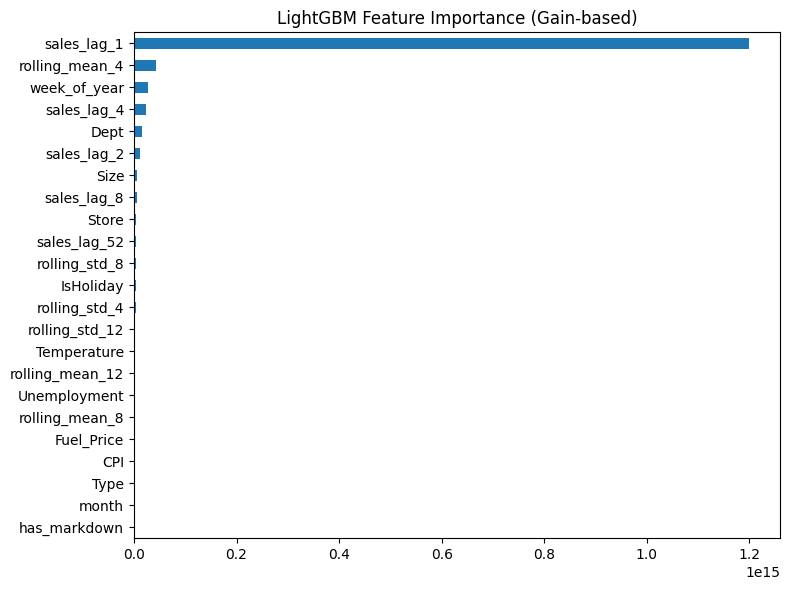

sales_lag_1        1.199887e+15
rolling_mean_4     4.352438e+13
week_of_year       2.729148e+13
sales_lag_4        2.414948e+13
Dept               1.510572e+13
sales_lag_2        1.090921e+13
Size               6.373497e+12
sales_lag_8        5.396881e+12
Store              3.800492e+12
sales_lag_52       3.493108e+12
rolling_std_8      3.330285e+12
IsHoliday          3.096820e+12
rolling_std_4      3.023681e+12
rolling_std_12     2.699584e+12
Temperature        1.982790e+12
rolling_mean_12    1.882335e+12
Unemployment       1.435231e+12
rolling_mean_8     1.413495e+12
Fuel_Price         1.114004e+12
CPI                7.452273e+11
Type               3.218650e+11
month              7.649958e+09
has_markdown       0.000000e+00
dtype: float64


In [20]:
importance_gain = pd.Series(
    model.booster_.feature_importance(importance_type='gain'),
    index=feature_list
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importance_gain.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('LightGBM Feature Importance (Gain-based)')
plt.tight_layout()
plt.show()

print(importance_gain)


In [16]:
drop_features = ['has_markdown', 'month', 'Type', 'CPI', 'Fuel_Price', 'Unemployment', 'Temperature']
selected_features = [f for f in feature_list if f not in drop_features]

X_train_sel, X_val_sel = tr_feat[selected_features], va_feat[selected_features]

with mlflow.start_run(run_name="LightGBM_Feature_Selection_v2"):
    mlflow.log_param("dropped_features", str(drop_features))
    mlflow.log_param("importance_type_used", "gain")
    mlflow.log_param("n_features_selected", len(selected_features))
    mlflow.log_metric("baseline_wmae", score)

    model_sel = lgb.LGBMRegressor(**params)
    model_sel.fit(X_train_sel, y_train, categorical_feature=['Dept', 'Store'])

    preds_sel = model_sel.predict(X_val_sel)
    score_sel = wmae(y_val, preds_sel, va_feat['IsHoliday'])

    mlflow.log_metric("val_wmae", score_sel)
    mlflow.log_metric("wmae_change", score_sel - score)

print("Full-feature WMAE:", score)
print("Selected-feature WMAE (v2):", score_sel)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 16
[LightGBM] [Info] Start training from score 15864.893370
🏃 View run LightGBM_Feature_Selection_v2 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/8eddf2094b2748029d218795918a39cd
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0
Full-feature WMAE: 1728.3197656776044
Selected-feature WMAE (v2): 1762.03011923171


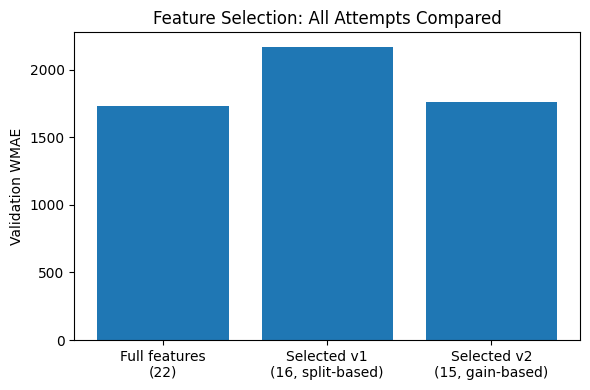

In [17]:
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Full features\n(22)', 'Selected v1\n(16, split-based)', 'Selected v2\n(15, gain-based)'],
       [score, 2167.514862319926, score_sel])
ax.set_ylabel('Validation WMAE')
ax.set_title('Feature Selection: All Attempts Compared')
plt.tight_layout()
plt.show()

# Training

In [25]:
def time_series_cv_folds(df, n_folds=3, fold_weeks=13):
    """Expanding-window folds, each entirely before VALIDATION_START,
    so they never leak into the real held-out validation set."""
    folds = []
    for i in range(n_folds):
        val_end = VALIDATION_START - pd.Timedelta(weeks=(n_folds - 1 - i) * fold_weeks)
        val_start = val_end - pd.Timedelta(weeks=fold_weeks)
        tr_fold = df[df['Date'] < val_start]
        va_fold = df[(df['Date'] >= val_start) & (df['Date'] < val_end)]
        folds.append((tr_fold, va_fold))
    return folds

folds = time_series_cv_folds(tr_feat, n_folds=3, fold_weeks=13)

for i, (tr_f, va_f) in enumerate(folds):
    print(f"Fold {i+1}: train up to {tr_f['Date'].max()} ({len(tr_f)} rows) "
          f"| val {va_f['Date'].min()} to {va_f['Date'].max()} ({len(va_f)} rows)")

Fold 1: train up to 2011-01-28 00:00:00 (152374 rows) | val 2011-02-04 00:00:00 to 2011-04-29 00:00:00 (38300 rows)
Fold 2: train up to 2011-04-29 00:00:00 (190674 rows) | val 2011-05-06 00:00:00 to 2011-07-29 00:00:00 (38164 rows)
Fold 3: train up to 2011-07-29 00:00:00 (228838 rows) | val 2011-08-05 00:00:00 to 2011-10-28 00:00:00 (38346 rows)


In [26]:
param_grid = [
    {'label': 'baseline',            'num_leaves': 63,  'learning_rate': 0.05, 'n_estimators': 500},
    {'label': 'fewer_leaves',        'num_leaves': 15,  'learning_rate': 0.05, 'n_estimators': 500},
    {'label': 'more_leaves',         'num_leaves': 127, 'learning_rate': 0.05, 'n_estimators': 500},
    {'label': 'deliberate_overfit',  'num_leaves': 255, 'learning_rate': 0.1,  'n_estimators': 1000, 'min_child_samples': 1},
    {'label': 'deliberate_underfit', 'num_leaves': 7,   'learning_rate': 0.3,  'n_estimators': 50},
    {'label': 'slow_and_steady',     'num_leaves': 63,  'learning_rate': 0.02, 'n_estimators': 1000},
    {'label': 'fast',                'num_leaves': 63,  'learning_rate': 0.15, 'n_estimators': 200},
    {'label': 'l1_l2_reg',           'num_leaves': 127, 'learning_rate': 0.05, 'n_estimators': 500, 'reg_alpha': 1.0, 'reg_lambda': 1.0},
    {'label': 'bagging',             'num_leaves': 63,  'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.8, 'colsample_bytree': 0.8, 'subsample_freq': 1},
    {'label': 'min_child_50',        'num_leaves': 63,  'learning_rate': 0.05, 'n_estimators': 500, 'min_child_samples': 50},
    {'label': 'combined_best_guess', 'num_leaves': 95,  'learning_rate': 0.03, 'n_estimators': 800, 'subsample': 0.8, 'colsample_bytree': 0.8, 'subsample_freq': 1, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'min_child_samples': 20},
]

results = []
for cfg in param_grid:
    label = cfg.pop('label')
    full_params = {**cfg, 'objective': 'regression', 'metric': 'mae', 'random_state': 42}

    with mlflow.start_run(run_name=f"LightGBM_{label}"):
        mlflow.log_param("label", label)
        mlflow.log_params(full_params)

        fold_scores = []
        for tr_f, va_f in folds:
            m = lgb.LGBMRegressor(**full_params)
            m.fit(tr_f[feature_list], tr_f['Weekly_Sales'], categorical_feature=['Type','Dept','Store'])
            preds_f = m.predict(va_f[feature_list])
            fold_scores.append(wmae(va_f['Weekly_Sales'], preds_f, va_f['IsHoliday']))

        cv_mean, cv_std = np.mean(fold_scores), np.std(fold_scores)
        mlflow.log_metric("cv_wmae_mean", cv_mean)
        mlflow.log_metric("cv_wmae_std", cv_std)

        m_full = lgb.LGBMRegressor(**full_params)
        m_full.fit(X_train, y_train, categorical_feature=['Type','Dept','Store'])
        val_score = wmae(y_val, m_full.predict(X_val), va_feat['IsHoliday'])
        mlflow.log_metric("held_out_val_wmae", val_score)

    results.append({'label': label, **cfg, 'cv_wmae_mean': cv_mean, 'cv_wmae_std': cv_std, 'held_out_val_wmae': val_score})

results_df = pd.DataFrame(results)
print(results_df[['label', 'cv_wmae_mean', 'cv_wmae_std', 'held_out_val_wmae']])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3687
[LightGBM] [Info] Number of data points in the train set: 152374, number of used features: 21
[LightGBM] [Info] Start training from score 16095.856820
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3983
[LightGBM] [Info] Number of data points in the train set: 190674, number of used features: 22
[LightGBM] [Info] Start training from score 15968.639532
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010517 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is

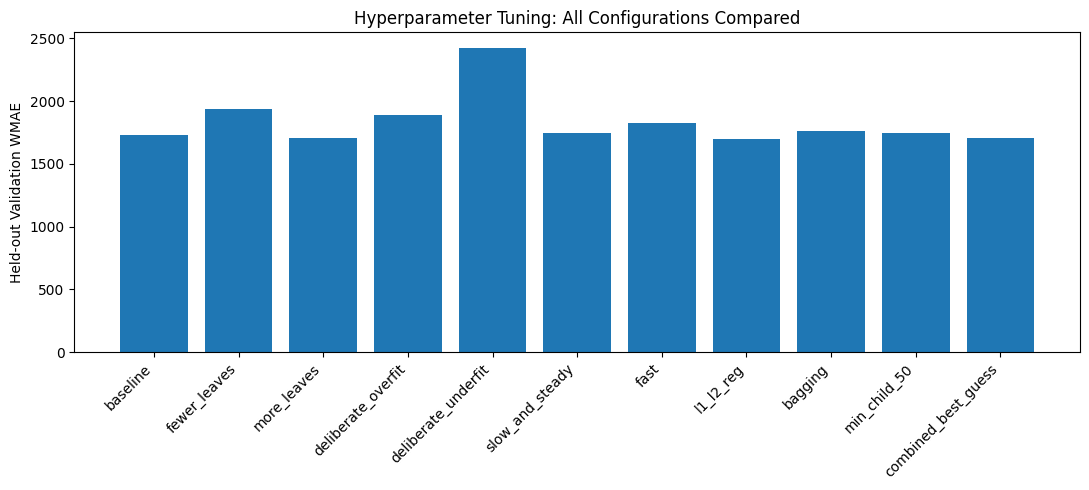

In [27]:
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(results_df['label'], results_df['held_out_val_wmae'])
ax.set_ylabel('Held-out Validation WMAE')
ax.set_title('Hyperparameter Tuning: All Configurations Compared')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Systematic Search (around best manual config)

In [28]:
from sklearn.model_selection import ParameterGrid

search_space = {
    'num_leaves': [63, 95, 127],
    'reg_alpha': [0.5, 1.0, 2.0],
    'reg_lambda': [0.5, 1.0, 2.0],
}

search_results = []
for cfg in ParameterGrid(search_space):
    full_params = {**cfg, 'learning_rate': 0.05, 'n_estimators': 500,
                    'objective': 'regression', 'metric': 'mae', 'random_state': 42}
    run_name = f"LightGBM_search_leaves{cfg['num_leaves']}_a{cfg['reg_alpha']}_l{cfg['reg_lambda']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(full_params)
        m = lgb.LGBMRegressor(**full_params)
        m.fit(X_train, y_train, categorical_feature=['Type','Dept','Store'])
        val_score = wmae(y_val, m.predict(X_val), va_feat['IsHoliday'])
        mlflow.log_metric("held_out_val_wmae", val_score)

    search_results.append({**cfg, 'held_out_val_wmae': val_score})

search_df = pd.DataFrame(search_results).sort_values('held_out_val_wmae')
print(search_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4041
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 22
[LightGBM] [Info] Start training from score 15864.893370
🏃 View run LightGBM_search_leaves63_a0.5_l0.5 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/2ca6acc806c645bb936749baa0df1ecc
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4041
[LightGBM] [Info] Number of data points in the 

In [38]:
best_config = {
    'num_leaves': 127,
    'reg_alpha': 0.5,
    'reg_lambda': 2.0,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'objective': 'regression',
    'metric': 'mae',
    'random_state': 42
}
print("Final selected LightGBM config:", best_config)

Final selected LightGBM config: {'num_leaves': 127, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'learning_rate': 0.05, 'n_estimators': 500, 'objective': 'regression', 'metric': 'mae', 'random_state': 42}


# Recursive Forecasting Pipeline

In [25]:
class WalmartForecastPipeline:
    """Raw data in, predictions out. Handles cleaning, feature engineering,
    and recursive week-by-week forecasting, since short-lag features need
    prior predictions once true future sales are unknown."""

    def __init__(self, params, feature_list):
        self.params = params
        self.feature_list = feature_list
        self.model = None
        self.history = None

    def fit(self, raw_train_merged):
        clean = preprocess(raw_train_merged)
        feat = add_features(clean)
        self.model = lgb.LGBMRegressor(**self.params)
        self.model.fit(feat[self.feature_list], feat['Weekly_Sales'],
                        categorical_feature=['Type', 'Dept', 'Store'])
        self.history = clean.copy()
        return self

    def predict(self, raw_test_merged):
        clean_test = preprocess(raw_test_merged)
        working_history = self.history.copy()
        all_preds = []

        for week in sorted(clean_test['Date'].unique()):
            week_rows = clean_test[clean_test['Date'] == week].copy()
            combined = pd.concat([working_history, week_rows], ignore_index=True, sort=False)
            combined_feat = add_features(combined.sort_values(['Store', 'Dept', 'Date']))
            this_week = combined_feat[combined_feat['Date'] == week]

            preds = self.model.predict(this_week[self.feature_list])
            week_rows = week_rows.reset_index(drop=True)
            week_rows['Weekly_Sales'] = preds
            all_preds.append(week_rows[['Store', 'Dept', 'Date', 'Weekly_Sales']])

            working_history = pd.concat(
                [working_history, week_rows.reindex(columns=working_history.columns)],
                ignore_index=True
            )

        return pd.concat(all_preds, ignore_index=True)

In [39]:
pipeline = WalmartForecastPipeline(params=best_config, feature_list=feature_list)
pipeline.fit(tr[tr['Date'] < VALIDATION_START]) 

val_test_shape = va.drop(columns=['Weekly_Sales']).copy()
recursive_preds = pipeline.predict(val_test_shape)

merged = recursive_preds.merge(va[['Store','Dept','Date','Weekly_Sales','IsHoliday']],
                                 on=['Store','Dept','Date'], suffixes=('_pred','_true'))
recursive_wmae = wmae(merged['Weekly_Sales_true'], merged['Weekly_Sales_pred'], merged['IsHoliday'])
print("Recursive forecast WMAE:", recursive_wmae)
print("Oracle (true-lag) WMAE for comparison:", 1696.79)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4041
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 22
[LightGBM] [Info] Start training from score 15864.893370
Recursive forecast WMAE: 2383.5144511563303
Oracle (true-lag) WMAE for comparison: 1696.79


/tmp/ipykernel_58/2682411419.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wmae_by_week = merged.groupby('weeks_ahead').apply(


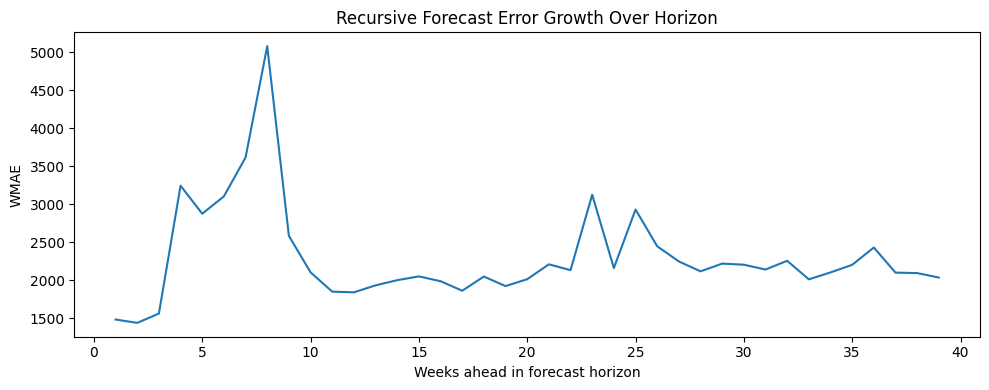

In [36]:
weeks_sorted = sorted(va['Date'].unique())
week_rank_map = {d: i+1 for i, d in enumerate(weeks_sorted)}
merged['weeks_ahead'] = merged['Date'].map(week_rank_map)

wmae_by_week = merged.groupby('weeks_ahead').apply(
    lambda g: wmae(g['Weekly_Sales_true'], g['Weekly_Sales_pred'], g['IsHoliday'])
)

fig, ax = plt.subplots(figsize=(10,4))
wmae_by_week.plot(ax=ax)
ax.set_xlabel('Weeks ahead in forecast horizon')
ax.set_ylabel('WMAE')
ax.set_title('Recursive Forecast Error Growth Over Horizon')
plt.tight_layout()
plt.show()

In [37]:
safe_feature_list = [f for f in feature_list if f not in
    ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8',
     'rolling_mean_4','rolling_mean_8','rolling_mean_12',
     'rolling_std_4','rolling_std_8','rolling_std_12']]
print(safe_feature_list)

pipeline_safe = WalmartForecastPipeline(params=best_config, feature_list=safe_feature_list)
pipeline_safe.fit(tr[tr['Date'] < VALIDATION_START])

recursive_preds_safe = pipeline_safe.predict(val_test_shape)
merged_safe = recursive_preds_safe.merge(va[['Store','Dept','Date','Weekly_Sales','IsHoliday']],
                                           on=['Store','Dept','Date'], suffixes=('_pred','_true'))
recursive_wmae_safe = wmae(merged_safe['Weekly_Sales_true'], merged_safe['Weekly_Sales_pred'], merged_safe['IsHoliday'])

print("Recursive WMAE, short lags included:", 2383.51)
print("Recursive WMAE, safe features only (lag_52 + calendar + store/dept + macro):", recursive_wmae_safe)

['sales_lag_52', 'week_of_year', 'month', 'has_markdown', 'Size', 'Type', 'Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday']
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1491
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 12
[LightGBM] [Info] Start training from score 15864.893370
Recursive WMAE, short lags included: 2383.51
Recursive WMAE, safe features only (lag_52 + calendar + store/dept + macro): 2195.5179142384663


# Lag Ablation Under Recursive Forecasting

In [39]:
def evaluate_feature_set(feats):
    pipe = WalmartForecastPipeline(params=best_config, feature_list=feats)
    pipe.fit(tr[tr['Date'] < VALIDATION_START])
    preds = pipe.predict(val_test_shape)
    m = preds.merge(va[['Store','Dept','Date','Weekly_Sales','IsHoliday']],
                     on=['Store','Dept','Date'], suffixes=('_pred','_true'))
    return wmae(m['Weekly_Sales_true'], m['Weekly_Sales_pred'], m['IsHoliday'])

feature_variants = {
    'safe_lag52_only': safe_feature_list,
    'safe_plus_lag8': safe_feature_list + ['sales_lag_8'],
    'safe_plus_lag8_rollmean12':safe_feature_list + ['sales_lag_8', 'rolling_mean_12'],
    'safe_plus_lag4_lag8': safe_feature_list + ['sales_lag_4', 'sales_lag_8'],
}

ablation_results = {}
for name, feats in feature_variants.items():
    score = evaluate_feature_set(feats)
    ablation_results[name] = score
    print(f"{name}: recursive WMAE = {score:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1491
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 12
[LightGBM] [Info] Start training from score 15864.893370
safe_lag52_only: recursive WMAE = 2195.52
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1746
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 13
[LightGBM] [Info] Start training from score 15864.893370
safe_plus_lag8: recursive WMAE = 2196.71
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008992 

🏃 View run LightGBM_Lag_Ablation at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/38a55618fabe4745ba34573e21cd7ad2
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


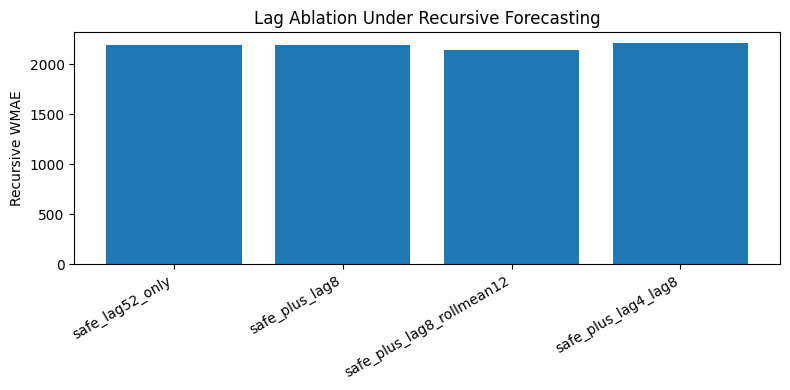

In [40]:
with mlflow.start_run(run_name="LightGBM_Lag_Ablation"):
    for name, score in ablation_results.items():
        mlflow.log_metric(f"wmae_{name}", score)

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(list(ablation_results.keys()), list(ablation_results.values()))
ax.set_ylabel('Recursive WMAE')
ax.set_title('Lag Ablation Under Recursive Forecasting')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Holiday-Week Blending (Model vs Seasonal-Naive)

In [20]:
def get_seasonal_naive(dates_df, history_df):
    lookup_df = dates_df[['Store','Dept','Date']].copy()
    lookup_df['lookup_date'] = lookup_df['Date'] - pd.Timedelta(weeks=52)
    merged = lookup_df.merge(
        history_df[['Store','Dept','Date','Weekly_Sales']].rename(
            columns={'Date': 'lookup_date', 'Weekly_Sales': 'seasonal_naive'}),
        on=['Store', 'Dept', 'lookup_date'], how='left'
    )
    return merged['seasonal_naive'].values

def blend_holiday_predictions(preds_df, history_df, holiday_flags_df, alpha=0.5):
    out = preds_df.merge(holiday_flags_df[['Store','Dept','Date','IsHoliday']],
                          on=['Store','Dept','Date'], how='left')
    out['seasonal_naive'] = get_seasonal_naive(out, history_df)
    mask = out['IsHoliday'].fillna(False) &out['seasonal_naive'].notna()
    out.loc[mask, 'Weekly_Sales'] = alpha * out.loc[mask, 'seasonal_naive'] + (1 - alpha)* out.loc[mask, 'Weekly_Sales']
    return out.drop(columns=['IsHoliday', 'seasonal_naive'])

In [42]:
best_ablation_name = min(ablation_results, key=ablation_results.get)
best_ablation_feats = feature_variants[best_ablation_name]
print("Best feature set from ablation:", best_ablation_name)

pipe_best = WalmartForecastPipeline(params=best_config, feature_list=best_ablation_feats)
pipe_best.fit(tr[tr['Date'] < VALIDATION_START])
preds_best = pipe_best.predict(val_test_shape)

blend_results = {}
for alpha in [0.0, 0.3, 0.5, 0.7, 1.0]:
    blended = blend_holiday_predictions(preds_best, tr, va[['Store','Dept','Date','IsHoliday']], alpha=alpha)
    m = blended.merge(va[['Store','Dept','Date','Weekly_Sales','IsHoliday']],
                       on=['Store','Dept','Date'], suffixes=('_pred','_true'))
    score = wmae(m['Weekly_Sales_true'], m['Weekly_Sales_pred'], m['IsHoliday'])
    blend_results[alpha] = score
    print(f"alpha={alpha}: WMAE={score:.2f}")

Best feature set from ablation: safe_plus_lag8_rollmean12
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2001
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 14
[LightGBM] [Info] Start training from score 15864.893370
alpha=0.0: WMAE=2145.20
alpha=0.3: WMAE=2043.54
alpha=0.5: WMAE=2001.03
alpha=0.7: WMAE=1987.57
alpha=1.0: WMAE=2044.81


🏃 View run LightGBM_Holiday_Blend at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/8a3ee445fc0c4e3caf868ad9229ca157
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


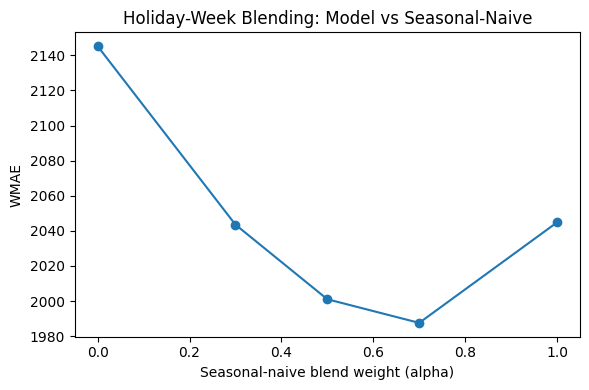

In [43]:
with mlflow.start_run(run_name="LightGBM_Holiday_Blend"):
    mlflow.log_param("base_feature_set", best_ablation_name)
    for alpha, score in blend_results.items():
        mlflow.log_metric(f"wmae_alpha_{alpha}", score)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(list(blend_results.keys()), list(blend_results.values()), marker='o')
ax.set_xlabel('Seasonal-naive blend weight (alpha)')
ax.set_ylabel('WMAE')
ax.set_title('Holiday-Week Blending: Model vs Seasonal-Naive')
plt.tight_layout()
plt.show()

# Holiday-Proximity Features

In [12]:
thanksgiving_dates = pd.to_datetime(["2010-11-26","2011-11-25","2012-11-23","2013-11-29"])
christmas_dates = pd.to_datetime(["2010-12-31","2011-12-30","2012-12-28","2013-12-27"])

def weeks_to_nearest(dates, reference_dates):
    """Signed weeks to the nearest occurrence of a holiday.
    Negative = before the holiday, positive = after."""
    d = pd.to_datetime(dates).values.astype('datetime64[D]')
    r = pd.to_datetime(reference_dates).values.astype('datetime64[D]')
    diffs = (d[:, None] - r[None, :]).astype('timedelta64[D]').astype(int) / 7.0
    idx = np.argmin(np.abs(diffs), axis=1)
    return diffs[np.arange(len(d)), idx]

def add_features(df):
    out = df.copy().sort_values(['Store', 'Dept', 'Date'])

    for lag in [1, 2, 4, 8, 52]:
        out[f'sales_lag_{lag}'] = out.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(lag)

    shifted = out.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
    for window in [4, 8, 12]:
        out[f'rolling_mean_{window}'] = shifted.groupby([out['Store'], out['Dept']]).transform(lambda s: s.rolling(window).mean())
        out[f'rolling_std_{window}'] = shifted.groupby([out['Store'], out['Dept']]).transform(lambda s: s.rolling(window).std())

    out['week_of_year'] = out['Date'].dt.isocalendar().week.astype(int)
    out['month'] = out['Date'].dt.month
    out['has_markdown'] = (out[MD_COLS].sum(axis=1) > 0).astype(int)
    out['weeks_to_thanksgiving'] = weeks_to_nearest(out['Date'], thanksgiving_dates)
    out['weeks_to_christmas'] = weeks_to_nearest(out['Date'], christmas_dates)

    out['Type'] = out['Type'].astype('category')
    out['Dept'] = out['Dept'].astype('category')
    out['Store'] = out['Store'].astype('category')

    return out

In [23]:
holiday_feats = best_ablation_feats + ['weeks_to_thanksgiving', 'weeks_to_christmas']

score_holiday = evaluate_feature_set(holiday_feats)
print(f"safe_plus_lag8_rollmean12 + holiday_proximity: recursive WMAE = {score_holiday:.2f}")
print(f"Previous best (no holiday features): {ablation_results[best_ablation_name]:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 16
[LightGBM] [Info] Start training from score 15864.893370
safe_plus_lag8_rollmean12 + holiday_proximity: recursive WMAE = 2166.51
Previous best (no holiday features): 2145.20


In [24]:
pipe_holiday = WalmartForecastPipeline(params=best_config, feature_list=holiday_feats)
pipe_holiday.fit(tr[tr['Date'] < VALIDATION_START])
preds_holiday = pipe_holiday.predict(val_test_shape)

blended_holiday = blend_holiday_predictions(preds_holiday, tr, va[['Store','Dept','Date','IsHoliday']], alpha=0.7)
m = blended_holiday.merge(va[['Store','Dept','Date','Weekly_Sales','IsHoliday']],
                            on=['Store','Dept','Date'], suffixes=('_pred','_true'))
score_holiday_blended = wmae(m['Weekly_Sales_true'], m['Weekly_Sales_pred'], m['IsHoliday'])
print(f"With holiday-proximity features + blend(alpha=0.7): {score_holiday_blended:.2f}")
print(f"Previous best(blend only, no holiday features): 1987.57")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 267184, number of used features: 16
[LightGBM] [Info] Start training from score 15864.893370
With holiday-proximity features + blend(alpha=0.7): 1998.58
Previous best(blend only, no holiday features): 1987.57


In [25]:
with mlflow.start_run(run_name="LightGBM_Holiday_Proximity_Features"):
    mlflow.log_metric("wmae_no_blend", score_holiday)
    mlflow.log_metric("wmae_with_blend", score_holiday_blended)
    mlflow.log_metric("previous_best_no_blend", ablation_results[best_ablation_name])
    mlflow.log_metric("previous_best_with_blend", 1987.57)

🏃 View run LightGBM_Holiday_Proximity_Features at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/19415bf72a474286b9a1a4690073b871
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


# Direct Multi-Horizon Modeling (No Recursion)

In [26]:
tr_feat_direct = add_features(tr)

horizons = [1,2,4,6,8,11,13,17,21,26,30,35,39]
target_cols = ['Weekly_Sales','week_of_year','month','IsHoliday','has_markdown',
               'Temperature','Fuel_Price','CPI','Unemployment']

frames = []
for h in horizons:
    shifted = tr_feat_direct.groupby(['Store','Dept'])[target_cols].shift(-h)
    shifted = shifted.rename(columns={c: f'target_{c}' for c in target_cols})
    frame = pd.concat([tr_feat_direct, shifted], axis=1)
    frame['h_ahead'] = h
    frame = frame.dropna(subset=['target_Weekly_Sales'])
    frames.append(frame)

direct_train = pd.concat(frames, ignore_index=True)
direct_train['Type'] = direct_train['Type'].astype('category')
direct_train['Dept'] = direct_train['Dept'].astype('category')
direct_train['Store'] = direct_train['Store'].astype('category')
print("Direct-horizon training rows:", direct_train.shape)

/tmp/ipykernel_58/1088015703.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_direct.groupby(['Store','Dept'])[target_cols].shift(-h)
/tmp/ipykernel_58/1088015703.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_direct.groupby(['Store','Dept'])[target_cols].shift(-h)
/tmp/ipykernel_58/1088015703.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_direct.groupby(

Direct-horizon training rows: (2815123, 42)


In [31]:
direct_feature_list = [
    'h_ahead','sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
    'rolling_mean_4','rolling_mean_8','rolling_mean_12',
    'rolling_std_4','rolling_std_8','rolling_std_12',
    'target_week_of_year','target_month','target_IsHoliday','target_has_markdown',
    'target_Temperature','target_Fuel_Price','target_CPI','target_Unemployment',
    'Size','Type','Store','Dept'
]

X_direct = direct_train[direct_feature_list]
y_direct = direct_train['target_Weekly_Sales']

with mlflow.start_run(run_name="LightGBM_Direct_Horizon"):
    mlflow.log_params(best_config)
    mlflow.log_param("horizons_sampled", str(horizons))
    mlflow.log_param("n_training_rows", len(direct_train))

    direct_model = lgb.LGBMRegressor(**best_config)
    direct_model.fit(X_direct, y_direct, categorical_feature=['Type','Dept','Store'])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4051
[LightGBM] [Info] Number of data points in the train set: 2815123, number of used features: 23
[LightGBM] [Info] Start training from score 16037.618329
🏃 View run LightGBM_Direct_Horizon at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/4818abf8653b43e89cc77dd16880b42f
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


In [32]:
origin_feat_cols = ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
                     'rolling_mean_4','rolling_mean_8','rolling_mean_12',
                     'rolling_std_4','rolling_std_8','rolling_std_12']

tr_with_feats = add_features(tr)
origin_rows = tr_with_feats.sort_values('Date').groupby(['Store','Dept']).tail(1)
origin_lookup = origin_rows[['Store','Dept','Date'] + origin_feat_cols].rename(columns={'Date':'origin_date'})

eval_df = va.merge(origin_lookup, on=['Store','Dept'], how='left')

n_before = len(eval_df)
eval_df = eval_df.dropna(subset=['origin_date'])
n_after = len(eval_df)
print(f"Dropped {n_before - n_after} rows with no matching training history (cold-start series)")

eval_df['h_ahead'] = ((eval_df['Date'] - eval_df['origin_date']).dt.days / 7).round().astype(int)

eval_df['target_week_of_year'] = eval_df['Date'].dt.isocalendar().week.astype(int)
eval_df['target_month'] = eval_df['Date'].dt.month
eval_df['target_has_markdown'] = (eval_df[MD_COLS].sum(axis=1) > 0).astype(int)
eval_df['target_IsHoliday'] = eval_df['IsHoliday']
eval_df['target_Temperature'] = eval_df['Temperature']
eval_df['target_Fuel_Price'] = eval_df['Fuel_Price']
eval_df['target_CPI'] = eval_df['CPI']
eval_df['target_Unemployment'] = eval_df['Unemployment']
eval_df['Type'] = eval_df['Type'].astype('category')
eval_df['Dept'] = eval_df['Dept'].astype('category')
eval_df['Store'] = eval_df['Store'].astype('category')

direct_preds = direct_model.predict(eval_df[direct_feature_list])
direct_wmae = wmae(eval_df['Weekly_Sales'], direct_preds, eval_df['IsHoliday'])

print("Direct multi-horizon WMAE:", direct_wmae)
print("Recursive + blend best so far:", 1987.57)

/tmp/ipykernel_58/880915447.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_rows = tr_with_feats.sort_values('Date').groupby(['Store','Dept']).tail(1)


Dropped 413 rows with no matching training history (cold-start series)
Direct multi-horizon WMAE: 1969.842590384337
Recursive + blend best so far: 1987.57


🏃 View run LightGBM_Direct_Horizon_Eval at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/6137be067b3a42c8b1312f79fdc97f5a
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


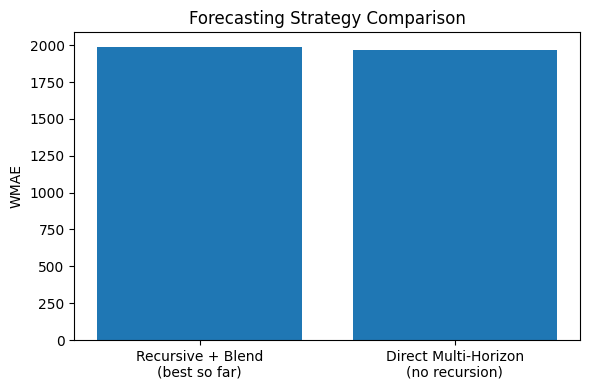

In [33]:
with mlflow.start_run(run_name="LightGBM_Direct_Horizon_Eval"):
    mlflow.log_metric("direct_horizon_wmae", direct_wmae)
    mlflow.log_metric("recursive_blend_best", 1987.57)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Recursive + Blend\n(best so far)', 'Direct Multi-Horizon\n(no recursion)'], [1987.57, direct_wmae])
ax.set_ylabel('WMAE')
ax.set_title('Forecasting Strategy Comparison')
plt.tight_layout()
plt.show()

In [34]:
eval_df_blend = eval_df[['Store','Dept','Date']].copy()
eval_df_blend['Weekly_Sales'] = direct_preds

blend_results_a2 = {}
for alpha in [0.0, 0.3, 0.5, 0.7, 1.0]:
    blended = blend_holiday_predictions(eval_df_blend, tr, eval_df[['Store','Dept','Date','IsHoliday']], alpha=alpha)
    merged_a2 = blended.merge(eval_df[['Store','Dept','Date','Weekly_Sales']].rename(columns={'Weekly_Sales':'true_sales'}),
                                on=['Store','Dept','Date'])
    score = wmae(merged_a2['true_sales'], merged_a2['Weekly_Sales'], eval_df['IsHoliday'])
    blend_results_a2[alpha] = score
    print(f"alpha={alpha}: WMAE={score:.2f}")

alpha=0.0: WMAE=1969.84
alpha=0.3: WMAE=1902.88
alpha=0.5: WMAE=1885.61
alpha=0.7: WMAE=1895.64
alpha=1.0: WMAE=1958.81


In [35]:
with mlflow.start_run(run_name="LightGBM_Direct_Horizon_Blend"):
    for alpha, score in blend_results_a2.items():
        mlflow.log_metric(f"wmae_alpha_{alpha}", score)
    mlflow.log_metric("best_alpha", 0.5)
    mlflow.log_metric("best_wmae", 1885.61)

🏃 View run LightGBM_Direct_Horizon_Blend at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/4cc3bbd5a7694c01afdeca755df2d23c
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


# Re-tuning Hyperparameters for Direct-Horizon Model

In [36]:
direct_search_space = [
    {'num_leaves': 127, 'learning_rate': 0.05, 'n_estimators': 500,  'reg_alpha': 0.5, 'reg_lambda': 2.0},
    {'num_leaves': 255, 'learning_rate': 0.05, 'n_estimators': 500,  'reg_alpha': 0.5, 'reg_lambda': 2.0},
    {'num_leaves': 255, 'learning_rate': 0.05, 'n_estimators': 1000, 'reg_alpha': 1.0, 'reg_lambda': 2.0},
    {'num_leaves': 511, 'learning_rate': 0.05, 'n_estimators': 1000, 'reg_alpha': 1.0, 'reg_lambda': 2.0},
    {'num_leaves': 255, 'learning_rate': 0.1,  'n_estimators': 500,  'reg_alpha': 1.0, 'reg_lambda': 2.0},
]

direct_tuning_results = []
for cfg in direct_search_space:
    full_params = {**cfg, 'objective': 'regression', 'metric': 'mae', 'random_state': 42}
    run_name = f"LightGBM_Direct_leaves{cfg['num_leaves']}_lr{cfg['learning_rate']}_trees{cfg['n_estimators']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(full_params)
        m = lgb.LGBMRegressor(**full_params)
        m.fit(X_direct, y_direct, categorical_feature=['Type','Dept','Store'])
        preds = m.predict(eval_df[direct_feature_list])
        score = wmae(eval_df['Weekly_Sales'], preds, eval_df['IsHoliday'])
        mlflow.log_metric("held_out_wmae", score)

    direct_tuning_results.append({**cfg, 'held_out_wmae': score})
    print(f"{run_name}: {score:.2f}")

direct_tuning_df = pd.DataFrame(direct_tuning_results).sort_values('held_out_wmae')
print(direct_tuning_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.141749 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4051
[LightGBM] [Info] Number of data points in the train set: 2815123, number of used features: 23
[LightGBM] [Info] Start training from score 16037.618329
🏃 View run LightGBM_Direct_leaves127_lr0.05_trees500 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/73eb39bf0e734da3896b2c06f9e9502b
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0
LightGBM_Direct_leaves127_lr0.05_trees500: 1969.84
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.142705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

In [37]:
best_direct_config = {
    'num_leaves': 511, 'learning_rate': 0.05, 'n_estimators': 1000,
    'reg_alpha': 1.0, 'reg_lambda': 2.0,
    'objective': 'regression', 'metric': 'mae', 'random_state': 42
}

In [38]:
direct_model_best = lgb.LGBMRegressor(**best_direct_config)
direct_model_best.fit(X_direct, y_direct, categorical_feature=['Type','Dept','Store'])
direct_preds_best = direct_model_best.predict(eval_df[direct_feature_list])

eval_df_blend2 = eval_df[['Store','Dept','Date']].copy()
eval_df_blend2['Weekly_Sales'] = direct_preds_best

blend_results_final = {}
for alpha in [0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]:
    blended = blend_holiday_predictions(eval_df_blend2, tr, eval_df[['Store','Dept','Date','IsHoliday']], alpha=alpha)
    merged = blended.merge(eval_df[['Store','Dept','Date','Weekly_Sales']].rename(columns={'Weekly_Sales':'true_sales'}),
                             on=['Store','Dept','Date'])
    score = wmae(merged['true_sales'], merged['Weekly_Sales'], eval_df['IsHoliday'])
    blend_results_final[alpha] = score
    print(f"alpha={alpha}: WMAE={score:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.142085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4051
[LightGBM] [Info] Number of data points in the train set: 2815123, number of used features: 23
[LightGBM] [Info] Start training from score 16037.618329
alpha=0.3: WMAE=1817.61
alpha=0.4: WMAE=1812.25
alpha=0.45: WMAE=1811.12
alpha=0.5: WMAE=1811.11
alpha=0.55: WMAE=1812.27
alpha=0.6: WMAE=1814.48
alpha=0.7: WMAE=1822.97


In [39]:
with mlflow.start_run(run_name="LightGBM_Direct_Retuned_Blend"):
    mlflow.log_params(best_direct_config)
    for alpha, score in blend_results_final.items():
        mlflow.log_metric(f"wmae_alpha_{alpha}", score)
    mlflow.log_metric("best_alpha", 0.5)
    mlflow.log_metric("best_wmae", 1811.11)

🏃 View run LightGBM_Direct_Retuned_Blend at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/7f3f37c884b74231ba76982b39130427
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


# True Target-Relative Seasonal Feature

In [40]:
direct_train['seasonal_naive_lookup_date'] = direct_train['Date'] - pd.to_timedelta(52 - direct_train['h_ahead'], unit='W')
lookup_source = tr_feat_direct[['Store','Dept','Date','Weekly_Sales']].rename(
    columns={'Date':'seasonal_naive_lookup_date', 'Weekly_Sales':'target_seasonal_naive'})
direct_train = direct_train.merge(lookup_source, on=['Store','Dept','seasonal_naive_lookup_date'], how='left')
direct_train = direct_train.drop(columns=['seasonal_naive_lookup_date'])

eval_df['target_seasonal_naive'] = get_seasonal_naive(eval_df[['Store','Dept','Date']], tr)

print("NaN in new feature(train):", direct_train['target_seasonal_naive'].isna().sum())
print("NaN in new feature (eval):", eval_df['target_seasonal_naive'].isna().sum())

NaN in new feature(train): 1375079
NaN in new feature (eval): 3110


In [41]:
direct_feature_list_v2 = direct_feature_list + ['target_seasonal_naive']
X_direct_v2 = direct_train[direct_feature_list_v2]
y_direct_v2 = direct_train['target_Weekly_Sales']

with mlflow.start_run(run_name="LightGBM_Direct_SeasonalFeature"):
    mlflow.log_params(best_direct_config)
    mlflow.log_param("added_feature", "target_seasonal_naive")

    model_v2 = lgb.LGBMRegressor(**best_direct_config)
    model_v2.fit(X_direct_v2, y_direct_v2, categorical_feature=['Type','Dept','Store'])
    preds_v2 = model_v2.predict(eval_df[direct_feature_list_v2])
    score_v2_noblend = wmae(eval_df['Weekly_Sales'], preds_v2, eval_df['IsHoliday'])
    mlflow.log_metric("wmae_no_blend", score_v2_noblend)

print("No blend, with seasonal feature:", score_v2_noblend)
print("Previous best (no blend, without this feature): 1856.76")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4306
[LightGBM] [Info] Number of data points in the train set: 2815123, number of used features: 24
[LightGBM] [Info] Start training from score 16037.618329
🏃 View run LightGBM_Direct_SeasonalFeature at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/4e386e060d104be6ba1d7fa0c121b753
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0
No blend, with seasonal feature: 1931.5881006404782
Previous best (no blend, without this feature): 1856.76


In [42]:
importance_v2 = pd.Series(model_v2.booster_.feature_importance(importance_type='gain'),
                            index=direct_feature_list_v2).sort_values(ascending=False)
print(importance_v2)

sales_lag_1              9.796149e+15
rolling_mean_4           1.809040e+15
Dept                     6.298708e+14
rolling_mean_8           5.288841e+14
target_week_of_year      5.253029e+14
target_seasonal_naive    3.840395e+14
Store                    1.922846e+14
sales_lag_2              1.714722e+14
sales_lag_8              1.497913e+14
rolling_mean_12          1.434979e+14
target_Temperature       6.204324e+13
target_Fuel_Price        4.909974e+13
rolling_std_12           3.582511e+13
target_Unemployment      3.273911e+13
target_CPI               2.578838e+13
sales_lag_4              2.383454e+13
Size                     2.302781e+13
h_ahead                  1.528056e+13
rolling_std_8            1.525415e+13
target_IsHoliday         1.110836e+13
rolling_std_4            7.248414e+12
Type                     2.774132e+12
target_month             1.018074e+12
sales_lag_52             8.606146e+11
target_has_markdown      0.000000e+00
dtype: float64


In [43]:
eval_df_blend3 = eval_df[['Store','Dept','Date']].copy()
eval_df_blend3['Weekly_Sales'] = preds_v2

blend_results_v2 = {}
for alpha in [0.0, 0.3, 0.45, 0.5, 0.55, 0.7]:
    blended = blend_holiday_predictions(eval_df_blend3, tr, eval_df[['Store','Dept','Date','IsHoliday']], alpha=alpha)
    merged = blended.merge(eval_df[['Store','Dept','Date','Weekly_Sales']].rename(columns={'Weekly_Sales':'true_sales'}),
                             on=['Store','Dept','Date'])
    score = wmae(merged['true_sales'], merged['Weekly_Sales'], eval_df['IsHoliday'])
    blend_results_v2[alpha] = score
    print(f"alpha={alpha}: WMAE={score:.2f}")

with mlflow.start_run(run_name="LightGBM_Direct_SeasonalFeature_Blend"):
    for alpha, score in blend_results_v2.items():
        mlflow.log_metric(f"wmae_alpha_{alpha}", score)

alpha=0.0: WMAE=1931.59
alpha=0.3: WMAE=1869.78
alpha=0.45: WMAE=1850.11
alpha=0.5: WMAE=1845.46
alpha=0.55: WMAE=1841.47
alpha=0.7: WMAE=1838.54
🏃 View run LightGBM_Direct_SeasonalFeature_Blend at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/55c7a622eb804210b8d7ed806a0e063a
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


In [44]:
with mlflow.start_run(run_name="LightGBM_SeasonalFeature_Conclusion"):
    mlflow.log_param("decision", "rejected")
    mlflow.log_param("reason", "48.8pct_missing_and_redundant_with_lag1")
    mlflow.log_metric("best_with_feature", 1838.54)
    mlflow.log_metric("best_without_feature", 1811.11)

🏃 View run LightGBM_SeasonalFeature_Conclusion at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/03c18ba46fb548dca40e00beec637a4c
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


In [45]:
direct_train['target_seasonal_naive'] = direct_train['target_seasonal_naive'].fillna(direct_train['rolling_mean_12'])
eval_df['target_seasonal_naive'] = eval_df['target_seasonal_naive'].fillna(eval_df['rolling_mean_12'])

In [46]:
X_direct_v2 = direct_train[direct_feature_list_v2]
y_direct_v2 = direct_train['target_Weekly_Sales']

with mlflow.start_run(run_name="LightGBM_Direct_SeasonalFeature_Filled"):
    mlflow.log_params(best_direct_config)
    mlflow.log_param("added_feature", "target_seasonal_naive_filled")

    model_v3 = lgb.LGBMRegressor(**best_direct_config)
    model_v3.fit(X_direct_v2, y_direct_v2, categorical_feature=['Type','Dept','Store'])
    preds_v3 = model_v3.predict(eval_df[direct_feature_list_v2])
    score_v3 = wmae(eval_df['Weekly_Sales'], preds_v3, eval_df['IsHoliday'])
    mlflow.log_metric("wmae_no_blend", score_v3)

print("No blend, filled seasonal feature:", score_v3)
print("Target to beat: 1856.76")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4306
[LightGBM] [Info] Number of data points in the train set: 2815123, number of used features: 24
[LightGBM] [Info] Start training from score 16037.618329
🏃 View run LightGBM_Direct_SeasonalFeature_Filled at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/90eaea1e3fe84c82b7f934683a3304c7
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0
No blend, filled seasonal feature: 2149.0149802349733
Target to beat: 1856.76


In [47]:
with mlflow.start_run(run_name="LightGBM_SeasonalFeature_Final_Conclusion"):
    mlflow.log_param("decision", "rejected_confirmed")
    mlflow.log_param("reason", "redundant_with_lag1_and_rolling_features_not_missingness")
    mlflow.log_metric("wmae_raw_nan", 1931.59)
    mlflow.log_metric("wmae_filled", 2149.01)
    mlflow.log_metric("best_without_feature", 1811.11)

🏃 View run LightGBM_SeasonalFeature_Final_Conclusion at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/c7c12fe0e2bb4aa0be504b2dcb5d48fb
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


In [49]:
final_blend = blend_holiday_predictions(eval_df_blend2, tr, eval_df[['Store','Dept','Date','IsHoliday']], alpha=0.5)
final_merged = final_blend.merge(eval_df[['Store','Dept','Date','Weekly_Sales','IsHoliday']],
                                    on=['Store','Dept','Date'], suffixes=('_pred','_true'))

holiday_names = {"2011-11-25":"Thanksgiving","2011-12-30":"Christmas","2012-02-10":"SuperBowl"}
final_merged['holiday_name'] = final_merged['Date'].dt.strftime('%Y-%m-%d').map(holiday_names).fillna('Regular')

breakdown = final_merged.groupby('holiday_name').apply(
    lambda g: wmae(g['Weekly_Sales_true'], g['Weekly_Sales_pred'], g['IsHoliday']))
print(breakdown)

holiday_name
Christmas       2420.198428
Regular         1704.160974
SuperBowl       1589.993933
Thanksgiving    2184.214801
dtype: float64


/tmp/ipykernel_58/1451229237.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  breakdown = final_merged.groupby('holiday_name').apply(


# Final Prediction Flow

In [28]:
df_test_clean = preprocess(df_test)
print("MarkDown NaNs remaining:", df_test_clean[MD_COLS].isna().sum().sum())
print("CPI NaNs remaining:", df_test_clean['CPI'].isna().sum())
print("Unemployment NaNs remaining:", df_test_clean['Unemployment'].isna().sum())

MarkDown NaNs remaining: 0
CPI NaNs remaining: 0
Unemployment NaNs remaining: 0


In [29]:
tr_feat_full = add_features(df_clean)

frames_full = []
for h in horizons:
    shifted = tr_feat_full.groupby(['Store','Dept'])[target_cols].shift(-h)
    shifted = shifted.rename(columns={c: f'target_{c}' for c in target_cols})
    frame = pd.concat([tr_feat_full, shifted], axis=1)
    frame['h_ahead'] = h
    frame = frame.dropna(subset=['target_Weekly_Sales'])
    frames_full.append(frame)

direct_train_full = pd.concat(frames_full, ignore_index=True)
direct_train_full['target_IsHoliday'] = direct_train_full['target_IsHoliday'].astype(bool)
direct_train_full['Type'] = direct_train_full['Type'].astype('category')
direct_train_full['Dept'] = direct_train_full['Dept'].astype('category')
direct_train_full['Store'] = direct_train_full['Store'].astype('category')
print("Full-history training rows:", direct_train_full.shape)

/tmp/ipykernel_58/11559699.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_full.groupby(['Store','Dept'])[target_cols].shift(-h)
/tmp/ipykernel_58/11559699.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_full.groupby(['Store','Dept'])[target_cols].shift(-h)
/tmp/ipykernel_58/11559699.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shifted = tr_feat_full.groupby(['Store','De

Full-history training rows: (4806902, 40)


In [15]:
X_direct_full = direct_train_full[direct_feature_list]
y_direct_full = direct_train_full['target_Weekly_Sales']

with mlflow.start_run(run_name="LightGBM_FINAL_MODEL"):
    mlflow.log_params(best_direct_config)
    mlflow.log_param("approach", "direct_multi_horizon")
    mlflow.log_param("blend_alpha", 0.5)
    mlflow.log_param("trained_on", "full_history")
    mlflow.log_metric("validation_wmae", 1811.11)

    final_model = lgb.LGBMRegressor(**best_direct_config)
    final_model.fit(X_direct_full, y_direct_full, categorical_feature=['Type','Dept','Store'])
    mlflow.lightgbm.log_model(final_model, "model")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.222705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4069
[LightGBM] [Info] Number of data points in the train set: 4806902, number of used features: 24
[LightGBM] [Info] Start training from score 16148.293476


2026/07/11 11:43:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LightGBM_FINAL_MODEL at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/065048286d2b4c54b7f1ab8fa1be2cf9
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


In [30]:
train_pairs_full = set(zip(df_clean.Store, df_clean.Dept))
test_pairs_full = set(zip(df_test_clean.Store, df_test_clean.Dept))
cold_pairs_final = test_pairs_full - train_pairs_full
print("Cold-start combos:", len(cold_pairs_final))

is_cold = df_test_clean.apply(lambda r: (r['Store'], r['Dept']) in cold_pairs_final, axis=1)
test_warm = df_test_clean[~is_cold].copy()
test_cold = df_test_clean[is_cold].copy()
print("Warm rows:", len(test_warm), "| Cold rows:", len(test_cold))

Cold-start combos: 11
Warm rows: 115028 | Cold rows: 36


In [31]:
origin_feat_cols_final = ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
                            'rolling_mean_4','rolling_mean_8','rolling_mean_12',
                            'rolling_std_4','rolling_std_8','rolling_std_12']

origin_rows_final = tr_feat_full.sort_values('Date').groupby(['Store','Dept']).tail(1)
origin_lookup_final = origin_rows_final[['Store','Dept','Date'] + origin_feat_cols_final].rename(columns={'Date':'origin_date'})

infer_df = test_warm.merge(origin_lookup_final, on=['Store','Dept'], how='left')
infer_df['h_ahead'] = ((infer_df['Date'] -infer_df['origin_date']).dt.days / 7).round().astype(int)
infer_df['target_week_of_year'] = infer_df['Date'].dt.isocalendar().week.astype(int)
infer_df['target_month'] = infer_df['Date'].dt.month
infer_df['target_has_markdown'] = (infer_df[MD_COLS].sum(axis=1) > 0).astype(int)
infer_df['target_IsHoliday'] = infer_df['IsHoliday']
infer_df['target_Temperature'] = infer_df['Temperature']
infer_df['target_Fuel_Price'] = infer_df['Fuel_Price']
infer_df['target_CPI'] = infer_df['CPI']
infer_df['target_Unemployment'] = infer_df['Unemployment']
infer_df['Type'] = infer_df['Type'].astype('category')
infer_df['Dept'] = infer_df['Dept'].astype('category')
infer_df['Store'] = infer_df['Store'].astype('category')

infer_df['Weekly_Sales'] = final_model.predict(infer_df[direct_feature_list])

warm_result = infer_df[['Store','Dept','Date','Weekly_Sales']].copy()
warm_result_blended = blend_holiday_predictions(warm_result, df_clean, infer_df[['Store','Dept','Date','IsHoliday']], alpha=0.5)
print(warm_result_blended.shape)

/tmp/ipykernel_58/399223504.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_rows_final = tr_feat_full.sort_values('Date').groupby(['Store','Dept']).tail(1)


(115028, 4)


In [32]:
cold_result = coldstart_fallback(df_clean, test_cold)
cold_result_final = cold_result[['Store','Dept','Date','y_fallback']].rename(columns={'y_fallback':'Weekly_Sales'})
print("Cold-start rows handled:", len(cold_result_final))

Cold-start rows handled: 36


In [33]:
final_predictions = pd.concat([
    warm_result_blended[['Store','Dept','Date','Weekly_Sales']],
    cold_result_final[['Store','Dept','Date','Weekly_Sales']]
], ignore_index=True)

final_predictions['Weekly_Sales'] = final_predictions['Weekly_Sales'].clip(lower=0)
final_predictions['Id'] = (final_predictions['Store'].astype(str) + '_' +
                            final_predictions['Dept'].astype(str) + '_' +
                            final_predictions['Date'].dt.strftime('%Y-%m-%d'))

submission = final_predictions[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)
assert len(submission) == len(test), f"Row mismatch: {len(submission)} vs {len(test)}"

submission.to_csv('submission.csv', index=False)
print(submission.shape)
print(submission.head())

(115064, 2)
                 Id  Weekly_Sales
0  10_10_2012-11-02  46783.745836
1  10_10_2012-11-09  47653.640174
2  10_10_2012-11-16  45468.549157
3  10_10_2012-11-23  47367.955107
4  10_10_2012-11-30  43827.127655


# Validation Reliability Check

In [57]:
VALIDATION_START_2 = pd.Timestamp("2010-11-05")
VALIDATION_END_2 = VALIDATION_START_2 + pd.Timedelta(weeks=39)

tr2 = df_clean[df_clean['Date'] < VALIDATION_START_2]
va2 = df_clean[(df_clean['Date'] >= VALIDATION_START_2) & (df_clean['Date'] < VALIDATION_END_2)]
print("tr2:", tr2.shape, "| va2:", va2.shape)

tr2: (114212, 16) | va2: (114626, 16)


In [58]:
val_test_shape_2 = va2.drop(columns=['Weekly_Sales']).copy()
best_ablation_feats_check = safe_feature_list + ['sales_lag_8', 'rolling_mean_12']

pipeline2 = WalmartForecastPipeline(params=best_config, feature_list=best_ablation_feats_check)
pipeline2.fit(tr2)
preds2 = pipeline2.predict(val_test_shape_2)

merged2 = preds2.merge(va2[['Store','Dept','Date','Weekly_Sales','IsHoliday']],
                          on=['Store','Dept','Date'], suffixes=('_pred','_true'))
wmae2_noblend = wmae(merged2['Weekly_Sales_true'], merged2['Weekly_Sales_pred'], merged2['IsHoliday'])

print("Window 2 (Nov 2010 -Jul 2011), no blend:", wmae2_noblend)
print("Window 1 (Nov 2011 - Jul 2012), no blend, reference: 2145.20")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1590
[LightGBM] [Info] Number of data points in the train set: 114212, number of used features: 13
[LightGBM] [Info] Start training from score 15736.281804
Window 2 (Nov 2010 -Jul 2011), no blend: 4456.097531772994
Window 1 (Nov 2011 - Jul 2012), no blend, reference: 2145.20


In [59]:
tr2_feat = add_features(tr2)
print("sales_lag_52 NaN rate in tr2:", tr2_feat['sales_lag_52'].isna().mean())
print("sales_lag_52 NaN rate in original tr (window 1):", add_features(tr)['sales_lag_52'].isna().mean())

sales_lag_52 NaN rate in tr2: 1.0
sales_lag_52 NaN rate in original tr (window 1): 0.5871908497514822


In [60]:
VALIDATION_START_3 = pd.Timestamp("2011-05-06")
VALIDATION_END_3 = VALIDATION_START_3 + pd.Timedelta(weeks=39)

tr3 = df_clean[df_clean['Date'] < VALIDATION_START_3]
va3 = df_clean[(df_clean['Date'] >= VALIDATION_START_3) & (df_clean['Date'] < VALIDATION_END_3)]

tr3_feat = add_features(tr3)
print("tr3:", tr3.shape, "| va3:", va3.shape)
print("sales_lag_52 NaN rate in tr3:", tr3_feat['sales_lag_52'].isna().mean())

tr3: (190674, 16) | va3: (115308, 16)
sales_lag_52 NaN rate in tr3: 0.8101786294932712


In [61]:
tr3_feat = add_features(tr3)
origin_check_3 = tr3_feat.sort_values('Date').groupby(['Store','Dept']).tail(1)
print("sales_lag_52 NaN rate AT ORIGIN (window 3):", origin_check_3['sales_lag_52'].isna().mean())

tr_feat_w1 = add_features(tr)
origin_check_1 = tr_feat_w1.sort_values('Date').groupby(['Store','Dept']).tail(1)
print("sales_lag_52 NaN rate AT ORIGIN (window 1, for comparison):", origin_check_1['sales_lag_52'].isna().mean())

/tmp/ipykernel_58/2585923938.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_check_3 = tr3_feat.sort_values('Date').groupby(['Store','Dept']).tail(1)


sales_lag_52 NaN rate AT ORIGIN (window 3): 0.11957868649318464
sales_lag_52 NaN rate AT ORIGIN (window 1, for comparison): 0.1038721573448064


/tmp/ipykernel_58/2585923938.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_check_1 = tr_feat_w1.sort_values('Date').groupby(['Store','Dept']).tail(1)


In [62]:
val_test_shape_3 = va3.drop(columns=['Weekly_Sales']).copy()

pipeline3 = WalmartForecastPipeline(params=best_config, feature_list=best_ablation_feats_check)
pipeline3.fit(tr3)
preds3 = pipeline3.predict(val_test_shape_3)

merged3 = preds3.merge(va3[['Store','Dept','Date','Weekly_Sales','IsHoliday']],
                          on=['Store','Dept','Date'], suffixes=('_pred','_true'))
wmae3_noblend = wmae(merged3['Weekly_Sales_true'], merged3['Weekly_Sales_pred'], merged3['IsHoliday'])

print("Window 3 (May 2011 - Jan 2012), no blend:", wmae3_noblend)
print("Window 1 (Nov 2011 - Jul 2012), no blend, reference: 2145.20")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1943
[LightGBM] [Info] Number of data points in the train set: 190674, number of used features: 14
[LightGBM] [Info] Start training from score 15968.639532
Window 3 (May 2011 - Jan 2012), no blend: 3168.2685686717573
Window 1 (Nov 2011 - Jul 2012), no blend, reference: 2145.20


# Wrap Final Model as Pipeline (pyfunc)

In [20]:
class LightGBMFinalPipeline(mlflow.pyfunc.PythonModel):
    def __init__(self, model, tr_feat_full, direct_feature_list, features_df, stores_df):
        self.model = model
        self.tr_feat_full = tr_feat_full
        self.direct_feature_list = direct_feature_list
        self.features_df = features_df
        self.stores_df = stores_df

    def predict(self, context, model_input):
        test_merged = load_and_merge(model_input.copy(), self.features_df, self.stores_df)
        test_clean = preprocess(test_merged)

        train_pairs = set(zip(self.tr_feat_full.Store, self.tr_feat_full.Dept))
        test_pairs = set(zip(test_clean.Store, test_clean.Dept))
        cold_pairs = test_pairs - train_pairs
        is_cold = test_clean.apply(lambda r: (r['Store'], r['Dept']) in cold_pairs, axis=1)
        test_warm, test_cold = test_clean[~is_cold].copy(), test_clean[is_cold].copy()

        origin_cols = ['sales_lag_1','sales_lag_2','sales_lag_4','sales_lag_8','sales_lag_52',
                       'rolling_mean_4','rolling_mean_8','rolling_mean_12',
                       'rolling_std_4','rolling_std_8','rolling_std_12']
        origin_lookup = (self.tr_feat_full.sort_values('Date').groupby(['Store','Dept']).tail(1)
                          [['Store','Dept','Date'] + origin_cols].rename(columns={'Date':'origin_date'}))

        infer_df = test_warm.merge(origin_lookup, on=['Store','Dept'], how='left')
        infer_df['h_ahead'] = ((infer_df['Date'] - infer_df['origin_date']).dt.days / 7).round().astype(int)
        infer_df['target_week_of_year'] = infer_df['Date'].dt.isocalendar().week.astype(int)
        infer_df['target_month'] = infer_df['Date'].dt.month
        infer_df['target_has_markdown'] = (infer_df[MD_COLS].sum(axis=1) > 0).astype(int)
        for col in ['IsHoliday','Temperature','Fuel_Price','CPI','Unemployment']:
            infer_df[f'target_{col}'] = infer_df[col]
        for col in ['Type','Dept','Store']:
            infer_df[col] = infer_df[col].astype('category')

        infer_df['Weekly_Sales'] = self.model.predict(infer_df[self.direct_feature_list])
        warm_result = blend_holiday_predictions(
            infer_df[['Store','Dept','Date','Weekly_Sales']], self.tr_feat_full,
            infer_df[['Store','Dept','Date','IsHoliday']], alpha=0.5)

        cold_result = coldstart_fallback(self.tr_feat_full, test_cold)
        cold_result = cold_result[['Store','Dept','Date','y_fallback']].rename(columns={'y_fallback':'Weekly_Sales'})

        final = pd.concat([warm_result, cold_result], ignore_index=True)
        final['Weekly_Sales'] = final['Weekly_Sales'].clip(lower=0)
        return final

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [21]:
pipeline_instance = LightGBMFinalPipeline(
    model=final_model,
    tr_feat_full=tr_feat_full,
    direct_feature_list=direct_feature_list,
    features_df=features,
    stores_df=stores
)

with mlflow.start_run(run_name="LightGBM_Pipeline_Wrapped"):
    mlflow.log_param("approach", "direct_multi_horizon_pipeline")
    mlflow.pyfunc.log_model(python_model=pipeline_instance, name="pipeline")

2026/07/11 11:52:59 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run LightGBM_Pipeline_Wrapped at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/cd2a8ec0e22745b595f38ec994d963cb
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


In [22]:
wrapped_preds = pipeline_instance.predict(None, test)
wrapped_preds['Id'] = (wrapped_preds['Store'].astype(str) + '_' +
                        wrapped_preds['Dept'].astype(str) + '_' +
                        wrapped_preds['Date'].dt.strftime('%Y-%m-%d'))
wrapped_submission = wrapped_preds[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)

old_submission = pd.read_csv('submission.csv')
comparison = wrapped_submission.merge(old_submission, on='Id', suffixes=('_wrapped','_original'))
comparison['diff'] = (comparison['Weekly_Sales_wrapped'] - comparison['Weekly_Sales_original']).abs()

print("Max difference:", comparison['diff'].max())
print("Rows matching:", (comparison['diff'] < 0.01).sum(), "/", len(comparison))

/tmp/ipykernel_58/3032094490.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_lookup = (self.tr_feat_full.sort_values('Date').groupby(['Store','Dept']).tail(1)
/tmp/ipykernel_58/3834383722.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()


Max difference: 5.820766091346741e-11
Rows matching: 115061 / 115064


In [35]:
final_predictions = pd.concat([
    warm_result_blended[['Store','Dept','Date','Weekly_Sales']],
    cold_result_final[['Store','Dept','Date','Weekly_Sales']]
], ignore_index=True)
final_predictions['Weekly_Sales'] = final_predictions['Weekly_Sales'].clip(lower=0)
final_predictions['Id'] = (final_predictions['Store'].astype(str) + '_' +
                            final_predictions['Dept'].astype(str) + '_' +
                            final_predictions['Date'].dt.strftime('%Y-%m-%d'))
submission = final_predictions[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)
submission.to_csv('submission.csv', index=False)

In [36]:
pipeline_instance = LightGBMFinalPipeline(
    model=final_model,
    tr_feat_full=tr_feat_full,
    direct_feature_list=direct_feature_list,
    features_df=features,
    stores_df=stores
)

with mlflow.start_run(run_name="LightGBM_Pipeline_Wrapped"):
    mlflow.log_param("approach", "direct_multi_horizon_pipeline")
    model_info = mlflow.pyfunc.log_model(python_model=pipeline_instance, name="pipeline")

loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)
reloaded_preds = loaded_model.predict(test)

reloaded_preds['Id'] = (reloaded_preds['Store'].astype(str) + '_' +
                          reloaded_preds['Dept'].astype(str) + '_' +
                          reloaded_preds['Date'].dt.strftime('%Y-%m-%d'))
reloaded_submission = reloaded_preds[['Id','Weekly_Sales']].sort_values('Id').reset_index(drop=True)

old_submission = pd.read_csv('submission.csv')
comparison = reloaded_submission.merge(old_submission, on='Id', suffixes=('_reloaded','_original'))
max_diff = (comparison['Weekly_Sales_reloaded'] - comparison['Weekly_Sales_original']).abs().max()
print("Max diff (reloaded model vs original submission):", max_diff)

2026/07/11 20:50:00 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run LightGBM_Pipeline_Wrapped at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0/runs/261459588a32436ca99d6ca029f9a6f7
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/0


/tmp/ipykernel_58/3032094490.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_lookup = (self.tr_feat_full.sort_values('Date').groupby(['Store','Dept']).tail(1)
/tmp/ipykernel_58/4016649777.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()


Max diff (reloaded model vs original submission): 5.820766091346741e-11
